# RAG-Pipeline Walkthrough

Begleitendes Notebook zur Erklaerung, zeigt pro Block echte Daten in genau der Form, wie sie durch die Pipeline laufen. Kein Ersatz fuer die eigentlichen Module (`rag_schema.py`, `idr_adapter.py`, ...) - importiert sie direkt, damit hier nichts doppelt gepflegt werden muss.

Blöcke:
1. Rohdaten (`metadata.json`)
2. Aufbereitung (`idr_adapter.py` - ein Bild wird zu mehreren Chunks)
3. Speicherung (Embedding + chromadb)
4. Suche zur Frage-Zeit (zwei Abrufe)
5. Antwort (Kontext-Text -> VLM)

In [1]:
import json
from pathlib import Path

DATA_ROOT = Path("..") / "data" / "idr"
IMAGE_ID = "6001240"  # Maus-Blastozyste, LaminB1/Dapi - dasselbe Beispiel wie im Gespraech

## Block 1: Die Rohdaten

**Meta-Ebene:** Fuer jedes IDR-Bild gibt es eine `metadata.json` mit allem, was IDR ueber den Datensatz weiss - grossteils frei formulierte Angaben der Forscher:innen, nicht standardisiert. Das ist die einzige Wahrheitsquelle, aus der alles Weitere gebaut wird.

**Woher sie kommt:** `fetch_from_idr.py` laedt sie einmalig beim Herunterladen eines Bildes von der IDR-API, unabhaengig vom RAG - das gab es schon vorher im Projekt.

In [2]:
raw = json.loads((DATA_ROOT / IMAGE_ID / "metadata.json").read_text(encoding="utf-8"))
print(json.dumps(raw, indent=2, ensure_ascii=False))

{
  "image_id": 6001240,
  "name": "B1_C1.tif",
  "description": null,
  "size": {
    "x": 271,
    "y": 275,
    "z": 236,
    "c": 2,
    "t": 1
  },
  "voxel_size_um": {
    "x": 0.3603981534640209,
    "y": 0.3603981534640209,
    "z": 0.5002025531914894
  },
  "channels": [
    "LaminB1",
    "Dapi"
  ],
  "key_values": {
    "Organism": "Mus musculus",
    "Protocol 1": "growth protocol - Mouse blastocysts (E3.5)",
    "Protocol 2": "Immunostaining: LaminB1 antibody: ab16048 (dilution 1:1000).",
    "Protocol 3": "Imaged with an Sp8 leica confocal microscope and HC PL APO 40x/1.30 Oil CS2  objective.  Nuclear features were extracted in PickCells using manually segmented nuclei in Nessys editor.",
    "Genotype": "Wild-type",
    "Genotype Comment": "Outbred MF1 mice",
    "Experiment Comment": "Images are used for benchmarking segmentation methods.",
    "Image File Type Comment": "Derived (cropped image)",
    "Segmented Image": "B1_C1.tif",
    "Segmented Channel": "LaminB1",


**Detail-Ebene:** zwei Zuverlaessigkeitsklassen in dieser einen Datei.

| Teil | Herkunft | Zuverlaessigkeit |
|---|---|---|
| `size`, `voxel_size_um`, `channels` | direkt aus den Pixel-Daten ausgelesen | strukturiert, immer vorhanden, immer gleiches Format |
| `key_values` | freie Text-Annotationen der Forscher:innen selbst | uneinheitlich - Feldnamen variieren zwischen Studien |

Zum Vergleich: dasselbe Feld bei einem ganz anderen Bild (Zebrafisch) - schon die Feldnamen unter `key_values` sind komplett andere.

In [3]:
other_raw = json.loads((DATA_ROOT / "9836950" / "metadata.json").read_text(encoding="utf-8"))
print("6001240 key_values Felder:", list(raw["key_values"].keys()))
print("9836950 key_values Felder:", list(other_raw["key_values"].keys()))

6001240 key_values Felder: ['Organism', 'Protocol 1', 'Protocol 2', 'Protocol 3', 'Genotype', 'Genotype Comment', 'Experiment Comment', 'Image File Type Comment', 'Segmented Image', 'Segmented Channel', 'Segmentation Method']
9836950 key_values Felder: ['Organism', 'Organism Part', 'Fluorescent Labels', 'Fluorescent Label Reference DOIs', 'Channels']


## Block 2: Die Aufbereitung (Adapter)

**Meta-Ebene:** Die rohe `metadata.json` wird nicht 1:1 gespeichert. Ein Adapter zerlegt sie in mehrere kleine, thematisch getrennte Text-Haeppchen - Chunks. Grund: bei "wie hergestellt" ist ein anderer Teil relevant als bei "was ist zu sehen" - ein Chunk pro Bild wuerde bei jeder Frage immer alles auf einmal liefern.

**Wie die Zerlegung funktioniert** (`idr_adapter.py`, `map_idr_metadata()`): geht `key_values` durch und baut daraus bis zu sechs Chunk-Typen (`field_type`), jeder nur falls die passenden Felder vorhanden sind.

In [4]:
import sys
sys.path.insert(0, str(Path(".").resolve()))
from idr_adapter import map_idr_metadata

chunks = map_idr_metadata(raw)
for c in chunks:
    print(f"[{c['field_type']:<12}] id={c['id']}\n  {c['text']}\n")

[overview    ] id=idr:6001240:overview:0
  Bild: B1_C1.tif. Kanaele/Marker: LaminB1, Dapi.

[resolution  ] id=idr:6001240:resolution:0
  Aufloesung: 0.36 x 0.36 x 0.50 µm/Voxel.

[overview    ] id=idr:6001240:overview:1
  Untersuchter Organismus: Mus musculus

[protocol    ] id=idr:6001240:protocol:0
  Verwendetes Wachstumsprotokoll: growth protocol - Mouse blastocysts (E3.5)

[protocol    ] id=idr:6001240:protocol:1
  Verwendete Faerbung: Immunostaining: LaminB1 antibody: ab16048 (dilution 1:1000).

[protocol    ] id=idr:6001240:protocol:2
  Verwendetes Mikroskop: Imaged with an Sp8 leica confocal microscope and HC PL APO 40x/1.30 Oil CS2  objective.

[segmentation] id=idr:6001240:segmentation:0
  Angewandte Segmentierungsmethode und segmentierter Kanal: Manual (Nessys Editor), LaminB1

[genotype    ] id=idr:6001240:genotype:0
  Genetischer Hintergrund: Wild-type

[genotype    ] id=idr:6001240:genotype:1
  Genetischer Kommentar: Outbred MF1 mice



**Detail-Ebene, ein Trick der beim Testen noetig wurde:** Protokoll-Texte sind reines englisches Fachjargon ("Immunostaining", "antibody"). Deutsche Fragen wie "welche Faerbung" trafen darauf beim Embedding-Vergleich schlechter (siehe Block 4). Fix: enthaelt ein Protokoll-Text ein Stain-Schluesselwort, wird automatisch "Diese Probe wurde gefaerbt:" vorangestellt - ueberbrueckt die Sprachluecke, ohne den Originaltext zu veraendern. Sichtbar oben am `protocol`-Chunk mit dem LaminB1-Antikoerper.

Kontrolle: wie viele Chunks bekommt ein Bild mit weniger Metadaten (der Zebrafisch von oben)?

**Wie dieser Trick gefunden wurde (kein LLM, keine vollstaendige Durchsicht):**

1. Beim ersten Lauf von `rag_test_questions.py` fiel EIN konkreter Fehlschlag auf: die Frage "Welche Faerbung wurde verwendet?" fand bei `6001240` den Genotyp-Chunk vor dem Faerbungs-Chunk - falsch gereiht.
2. Diagnose per direktem Experiment: mehrere deutsche Umformulierungen des Faerbungs-Textes gebaut und mit `embed_texts()` gegen die Frage verglichen, die Distanz jeweils gemessen - reines Ausprobieren, kein Modell hat "verstanden" worum es geht.
3. Die Version mit vorangestelltem "Diese Probe wurde gefaerbt:" hatte die kleinste Distanz -> als feste Regel uebernommen: eine Liste von sechs englischen Stichwoertern (`STAIN_KEYWORDS`), simples `in text.lower()`-Pruefen, kein LLM-Aufruf zur Laufzeit.

**Einschraenkung:** das ist eine Heuristik fuer genau diesen EINEN beobachteten Fall, keine allgemeine Loesung. Nur die 9 festen Testfragen wurden ueberprueft, nicht alle 23 lokal vorhandenen Bilder systematisch auf aehnliche Sprachluecken durchsucht. Ein Protokolltext, der Faerbung anders beschreibt (z.B. nur "conjugated", "IHC"), bekaeme die Bruecke nicht und koennte denselben Fehlschlag erneut zeigen. Eine robustere (aber teurere) Alternative waere ein LLM-Aufruf pro Chunk beim Indexieren - bewusst nicht gebaut, weil die Stichwortliste fuer den aktuellen Datensatz gereicht hat.

In [5]:
other_chunks = map_idr_metadata(other_raw)
print(f"6001240 (Maus, viele Protocol-Felder): {len(chunks)} chunks")
print(f"9836950 (Zebrafisch, wenig key_values): {len(other_chunks)} chunks")
for c in other_chunks:
    print(f"  [{c['field_type']}] {c['text']}")

6001240 (Maus, viele Protocol-Felder): 9 chunks
9836950 (Zebrafisch, wenig key_values): 7 chunks
  [overview] Bild: 056F63395C. Kanaele/Marker: lynEGFP.
  [resolution] Aufloesung: 0.10 x 0.10 x 0.22 µm/Voxel.
  [overview] Dargestellter Organismus: Danio rerio
  [overview] Dargestellter Gewebeteil: primary posterior lateral line primordium
  [protocol] Verwendete Fluoreszenzmarkierung: cldnB:lyn-EGFP
  [protocol] Referenz-DOI fuer Fluoreszenzmarkierung: 10.1016/j.devcel.2006.02.019
  [segmentation] Segmentierter Kanal: lynEGFP:cell membranes


## Block 3: Die Speicherung

**Meta-Ebene:** Jeder Chunk-Text wird in einen Vektor umgerechnet (viele Zahlen, die seine Bedeutung repraesentieren - aehnliche Inhalte bekommen aehnliche Vektoren). Diese Vektoren werden dauerhaft in einer lokalen Vektor-Datenbank abgelegt.

**Zwei Teilschritte:**
1. **Embedding** (`rag_embeddings.py`) - Text rein, Vektor raus. Laeuft ueber die ScaDS.AI Gateway (`Qwen/Qwen3-Embedding-4B`), gleicher API-Key wie Chat/Vision/STT im Rest des Projekts. Kein neues lokales Modell.
2. **Ablage** (`rag_index.py`) - chromadb, lokal, persistent unter `data/rag_index/`.

Ein einzelner Chunk-Text als Vektor, zur Anschauung (die ersten paar von 2560 Zahlen):

In [6]:
from rag_embeddings import embed_texts

example_chunk = chunks[0]
[vector] = embed_texts([example_chunk["text"]])
print("Text:  ", example_chunk["text"])
print("Vektor-Laenge:", len(vector))
print("erste 8 Werte:", [round(v, 4) for v in vector[:8]])

Text:   Bild: B1_C1.tif. Kanaele/Marker: LaminB1, Dapi.
Vektor-Laenge: 2560
erste 8 Werte: [-0.0002, -0.0677, -0.0215, -0.0095, -0.0007, 0.0578, -0.0038, -0.0348]


**Detail-Ebene, ein wichtiger Punkt:** die Embeddings werden hier immer selbst berechnet und explizit an chromadb uebergeben - nie chromadb das Rechnen ueberlassen. Sonst wuerde chromadb im Hintergrund sein eigenes, anderes lokales Modell nachladen (unerwuenschte versteckte Abhaengigkeit).

Was letztlich pro Chunk in der Datenbank landet - id, Vektor (hier nicht ausgedruckt, zu lang), Text, Metadaten:

| Feld | Beispiel |
|---|---|
| `id` | `idr:6001240:protocol:1` |
| Vektor | 2560 Zahlen |
| `document` (Text) | "Diese Probe wurde gefaerbt: Immunostaining: LaminB1 antibody..." |
| Metadaten | `source_db="idr"`, `source_id="6001240"`, `field_type="protocol"` |

Der komplette Index ist schon gebaut (`build_rag_index.py` lief bereits) - hier nur nachschauen, wie viele Chunks tatsaechlich drinstehen:

In [7]:
from rag_index import get_collection

collection = get_collection()
print("Anzahl Chunks im Index insgesamt:", collection.count())

Anzahl Chunks im Index insgesamt: 216


## Block 4: Die Suche zur Frage-Zeit

**Meta-Ebene:** Bei einer Frage wird ihr eigener Vektor berechnet und mit allen gespeicherten Chunk-Vektoren verglichen - je naeher zwei Vektoren beieinander liegen (kleinere `distance`), desto aehnlicher der Inhalt. Die naechsten Treffer werden zurueckgegeben.

**Bei uns laufen zwei Suchen gleichzeitig, nicht nur eine:**

| Abruf | Filter | Zweck |
|---|---|---|
| 1 | nur Chunks des aktuell geladenen Bildes | Welcher Teil seiner eigenen Metadaten passt zur Frage |
| 2 | kein Filter, ganzer Index | Findet automatisch aehnliche Chunks aus ANDEREN Bildern |

Abruf 1, gefiltert auf das aktuelle Bild:

In [8]:
from rag_index import query

QUESTION = "Wie wurde diese Probe gefaerbt?"

own_hits = query(QUESTION, n_results=4, source_id=IMAGE_ID)
for h in own_hits:
    print(f"({h['distance']:.3f}) [{h['metadata']['field_type']}] {h['text']}")

(1.176) [protocol] Verwendete Faerbung: Immunostaining: LaminB1 antibody: ab16048 (dilution 1:1000).
(1.291) [overview] Untersuchter Organismus: Mus musculus
(1.294) [genotype] Genetischer Kommentar: Outbred MF1 mice
(1.360) [genotype] Genetischer Hintergrund: Wild-type


Der Faerbungs-Chunk liegt vorn (kleinste `distance`) - genau der Teil der Metadaten, der zur Frage passt, nicht z.B. der Genotyp-Chunk.

Abruf 2, komplett ungefiltert ueber den ganzen Index (145 Chunks aus 23 Bildern) - findet aehnliche Chunks auch in ANDEREN Bildern:

In [9]:
all_hits = query(QUESTION, n_results=8)
for h in all_hits:
    mark = "(dieses Bild)" if h["metadata"]["source_id"] == IMAGE_ID else f"(Bild {h['metadata']['source_id']})"
    print(f"({h['distance']:.3f}) {mark:<16} [{h['metadata']['field_type']}] {h['text'][:80]}")

(1.105) (Bild 6001254)   [protocol] Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000), clarified with
(1.105) (Bild 6001256)   [protocol] Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000), clarified with
(1.106) (Bild 6001255)   [protocol] Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000), clarified with
(1.107) (Bild 6001257)   [protocol] Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000), clarified with
(1.135) (Bild 6001239)   [phenotype] Beobachteter Phaenotyp: Keine Information
(1.147) (Bild 1884807)   [overview] Untersuchte Zelllinie: HeLa
(1.163) (Bild 6001258)   [protocol] Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000)
(1.172) (Bild 6001251)   [protocol] Verwendete Faerbung: Immunostaining: LaminB1 antibody: ab16048 (dilution 1:1000)


**Detail-Ebene:** hier tauchen andere Maus-Blastozysten-Bilder auf, die ebenfalls mit LaminB1-Antikoerper gefaerbt wurden - reines Nebenprodukt der Vektor-Aehnlichkeit, kein separates "Suchfeature". Fuer den fertigen Kontext (Block 5) werden aus diesem Abruf nur Treffer genommen, die NICHT zum aktuellen Bild gehoeren (sonst gaebe es Dopplungen mit Abruf 1).

## Block 5: Der fertige Kontext -> VLM

**Meta-Ebene:** Die Treffer aus beiden Abrufen werden zu einem einzigen Text zusammengesetzt, klar in zwei Abschnitte getrennt ("Aktuelles Bild:" / "Vergleichbare Datensaetze:"), damit das VLM nicht vermischt was zum betrachteten Bild gehoert und was nur Vergleichskontext ist. Dieser Text wird als eigene System-Nachricht vor die eigentliche Frage gehaengt.

Genau die Logik, die auch `upload_server.py`'s `/rag_query`-Endpunkt fuer die App bereitstellt (hier lokal nachgebaut zur Anschauung):

In [10]:
other_hits = [h for h in all_hits if h["metadata"]["source_id"] != IMAGE_ID][:3]

parts = ["Aktuelles Bild:"]
parts += [f"- {h['text']}" for h in own_hits]
parts.append("Vergleichbare Datensaetze:")
parts += [f"- (Bild {h['metadata']['source_id']}) {h['text']}" for h in other_hits]

context_text = "\n".join(parts)
print(context_text)

Aktuelles Bild:
- Verwendete Faerbung: Immunostaining: LaminB1 antibody: ab16048 (dilution 1:1000).
- Untersuchter Organismus: Mus musculus
- Genetischer Kommentar: Outbred MF1 mice
- Genetischer Hintergrund: Wild-type
Vergleichbare Datensaetze:
- (Bild 6001254) Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000), clarified with BABB before imaging.
- (Bild 6001256) Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000), clarified with BABB before imaging.
- (Bild 6001255) Verwendete Faerbung: LaminB1 antibody: ab16048 (dilution 1:1000), clarified with BABB before imaging.


**Detail-Ebene, wo dieser Text ankommt:**

- **In der App** (`VLMClient.cs`): als eigene `{"role": "system", "content": "<dieser Text>"}`-Nachricht VOR der User-Frage.
- **Im Browser-Tester** (`vlm_playground.py`, Menu "Mit RAG"): vor den eigenen System-Prompt-Text gehaengt, editierbar bevor man fragt.
- **In beiden Faellen dann:** `POST https://llm.scads.ai/v1/chat/completions` mit Bild + Frage + diesem Kontext.

Damit ist die Kette komplett: `metadata.json` -> Chunks -> Vektoren -> Suche (2x) -> Kontext-Text -> VLM-Antwort. Zum Vergleich "macht das ueberhaupt einen Unterschied" lohnt sich der "Vergleichen: mit vs. ohne RAG-Kontext"-Knopf im Browser-Tester - schickt dieselbe Frage einmal mit, einmal ohne diesen Text.

## Block 6: Automatisierte Auswertung - stimmen die harten Fakten?

**Meta-Ebene:** Bisher wurde nur EIN Beispiel Schritt fuer Schritt angeschaut. Fuer
manche Metadaten-Felder gibt es aber eine eindeutig richtige Antwort (Genotyp,
Organismus, Segmentierungsmethode, segmentierter Kanal, Voxel-Aufloesung) - die
lassen sich automatisiert pruefen statt jede Antwort von Hand zu lesen.

**Wichtig fuer die Fairness des Tests:** die Ground Truth kommt NICHT aus
`llm_chunker.py` (dem Modul das gerade getestet wird), sondern direkt und mit
eigenen festen Feldnamen aus den rohen Metadaten (`rag_ground_truth.py`). Sonst
wuerde der Test den Klassifizierer gegen seine eigene Ausgabe pruefen.

In [11]:
from rag_ground_truth import QUESTIONS, extract_hard_facts

hard_facts = extract_hard_facts(raw)
for fact_type, expected in hard_facts.items():
    print(f"{fact_type:<20} erwartet={expected!r}")
    print(f"{'':<20} frage={QUESTIONS[fact_type]!r}")

organism             erwartet='Mus musculus'
                     frage='Welcher Organismus ist auf diesem Bild zu sehen?'
genotype             erwartet='Wild-type'
                     frage='Welcher Genotyp liegt bei dieser Probe vor?'
segmentation_method  erwartet='Manual (Nessys Editor)'
                     frage='Wie wurde dieses Bild segmentiert?'
segmented_channel    erwartet='LaminB1'
                     frage='Welcher Kanal wurde in diesem Bild segmentiert?'
resolution           erwartet='0.36, 0.36, 0.50'
                     frage='Wie gross ist ein Voxel in diesem Bild, in Mikrometern?'


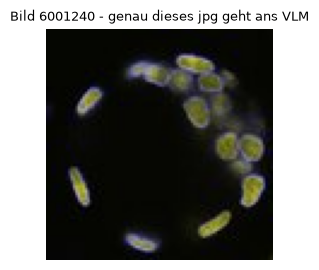

In [12]:
import matplotlib.pyplot as plt
from rag_eval import _thumbnail_bytes

# genau das bild, das gleich zusammen mit frage+kontext ans vlm geschickt wird -
# ein 2d thumbnail von idr, NICHT das 3d volumen (siehe rag_eval.py docstring).
# absichtlich hier angeschaut: macht sichtbar wie wenig man auf so einem kleinen
# thumbnail vom genotyp/segmentierungsdetails erkennen kann - das VLM kann diese
# harten fakten nur ueber den rag kontext wissen, nicht ueber das bild selbst
demo_thumb_path = DATA_ROOT / IMAGE_ID / "thumbnail.jpg"
if not demo_thumb_path.is_file():
    demo_thumb_path.write_bytes(_thumbnail_bytes(IMAGE_ID))

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(plt.imread(demo_thumb_path))
ax.set_title(f"Bild {IMAGE_ID} - genau dieses jpg geht ans VLM", fontsize=9)
ax.axis("off")
plt.show()

**Eine Frage live durch die komplette Kette schicken** (echter VLM-Call mit Bild +
RAG-Kontext, wie in der App): `rag_eval.py` macht das fuer alle Bilder x Fakten auf
einmal, hier nur EIN Beispiel zum Zusehen. Grading ist ein Wortstamm-Vergleich
(`_grade()`) statt exaktem String - das VLM antwortet auf Deutsch und uebersetzt
z.b. "Manual" konsequent zu "Manuell", ein exakter Vergleich wuerde das faelschlich
als falsch werten.

In [13]:
from rag_eval import _ask_vlm, _grade, _rag_context, _thumbnail_bytes

demo_fact = "genotype"
demo_question = QUESTIONS[demo_fact]
demo_expected = hard_facts[demo_fact]

demo_context = _rag_context(demo_question, IMAGE_ID)
demo_image = _thumbnail_bytes(IMAGE_ID)
demo_answer = _ask_vlm(demo_question, demo_context, demo_image)
demo_correct = _grade(demo_fact, demo_expected, demo_answer)

print("Frage:   ", demo_question)
print("Erwartet:", demo_expected)
print("Antwort: ", demo_answer)
print("Richtig? ", demo_correct)

Frage:    Welcher Genotyp liegt bei dieser Probe vor?
Erwartet: Wild-type
Antwort:  Der Genotyp bei dieser Probe ist **Wild-type**.
Richtig?  True


**Alle Fragen-Vorlagen im Ueberblick** (`rag_ground_truth.QUESTIONS`) - jede wird pro
Bild gestellt, bei dem das zugehoerige Feld in den rohen Metadaten vorhanden ist:

In [14]:
for fact_type, question in QUESTIONS.items():
    print(f"{fact_type:<20} {question}")

organism             Welcher Organismus ist auf diesem Bild zu sehen?
genotype             Welcher Genotyp liegt bei dieser Probe vor?
segmentation_method  Wie wurde dieses Bild segmentiert?
segmented_channel    Welcher Kanal wurde in diesem Bild segmentiert?
resolution           Wie gross ist ein Voxel in diesem Bild, in Mikrometern?


## Block 7: Der volle Lauf - 100 Fragen ueber alle 23 lokalen Bilder

Der Einzel-Fall oben lief live. Fuer alle Bilder auf einmal gibt es
`rag_eval.py` (schreibt `data/rag_eval_results.csv`) und `rag_eval_report.py`
(baut die Grafiken unten aus der CSV). Hier nur das Ergebnis nachschauen, nicht
neu rechnen - 100 VLM-Anfragen dauern ein paar Minuten und kosten API-Zeit.

**Erst zur Grading-Methode, bevor die 100% unten unkritisch geglaubt werden:**
Grading ist ein Wortstamm-Vergleich (`rag_eval._grade()`), kein exakter
String-Vergleich und kein LLM-als-Richter. Grund: das VLM antwortet auf
Deutsch und uebersetzt englische Fachbegriffe aus den Metadaten konsequent
(z.b. "Manual" -> "Manuell"). Ein Beispiel aus den echten Rohdaten, bei dem
ein exakter Vergleich faelschlich "falsch" gemeldet haette:

In [15]:
import csv

from rag_eval import OUTPUT_CSV, _grade

with open(OUTPUT_CSV, encoding="utf-8") as f:
    all_rows = list(csv.DictReader(f))

example = next(r for r in all_rows if r["fact_type"] == "segmentation_method")
exact_match = example["expected"].lower() in example["answer"].lower()
stem_match = _grade(example["fact_type"], example["expected"], example["answer"])

print("Erwartet:            ", example["expected"])
print("VLM-Antwort:          ", example["answer"].replace(chr(10), " "))
print("Exakter Substring?   ", exact_match, " <- waere faelschlich 'falsch'")
print("Wortstamm-Vergleich? ", stem_match, " <- tatsaechlich inhaltlich richtig")

Erwartet:             Manual (Nessys Editor)
VLM-Antwort:           Basierend auf den von Ihnen bereitgestellten Informationen wurde dieses Bild mit der folgenden Methode segmentiert:  **Manuell (unter Verwendung des Nessys Editors).**
Exakter Substring?    False  <- waere faelschlich 'falsch'
Wortstamm-Vergleich?  True  <- tatsaechlich inhaltlich richtig


**Ein paar weitere Beispielbilder**, die genauso ans VLM gingen (2D-Thumbnails von
IDR) - zeigt die Bandbreite der lokalen Testdaten (Maus-Blastozysten, HeLa-Zellen,
Zebrafisch):

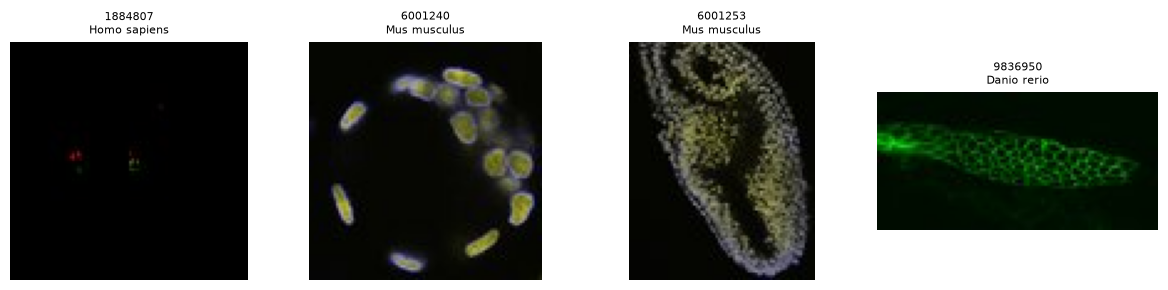

In [16]:
gallery_ids = ["1884807", "6001240", "6001253", "9836950"]

fig, axes = plt.subplots(1, len(gallery_ids), figsize=(3 * len(gallery_ids), 3))
for ax, gallery_id in zip(axes, gallery_ids):
    thumb_path = DATA_ROOT / gallery_id / "thumbnail.jpg"
    if not thumb_path.is_file():
        thumb_path.write_bytes(_thumbnail_bytes(gallery_id))
    gallery_raw = json.loads((DATA_ROOT / gallery_id / "metadata.json").read_text(encoding="utf-8"))
    organism = (gallery_raw.get("key_values") or {}).get("Organism", "?")
    ax.imshow(plt.imread(thumb_path))
    ax.set_title(f"{gallery_id}\n{organism}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [17]:
from collections import defaultdict

by_fact = defaultdict(list)
for row in all_rows:
    by_fact[row["fact_type"]].append(row["correct"] == "True")

print(f"{'fakt-typ':<24} {'n':>4} {'richtig':>8} {'quote':>7}")
for fact_type, results in sorted(by_fact.items()):
    n = len(results)
    correct = sum(results)
    print(f"{fact_type:<24} {n:>4} {correct:>8} {correct / n:>6.0%}")

total_correct = sum(r["correct"] == "True" for r in all_rows)
print(f"\ngesamt: {total_correct}/{len(all_rows)} ({total_correct / len(all_rows):.0%})")

fakt-typ                    n  richtig   quote
genotype                   16       16   100%
organism                   23       23   100%
resolution                 23       23   100%
segmentation_method        19       19   100%
segmented_channel          19       19   100%

gesamt: 100/100 (100%)


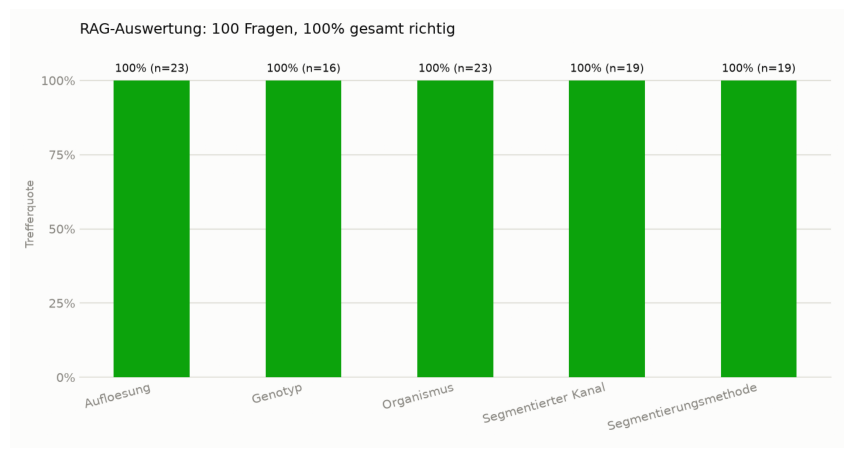

In [18]:
img = plt.imread(DATA_ROOT.parent / "rag_eval_report.png")
fig, ax = plt.subplots(figsize=(11, 5.7))
ax.imshow(img)
ax.axis("off")
plt.show()

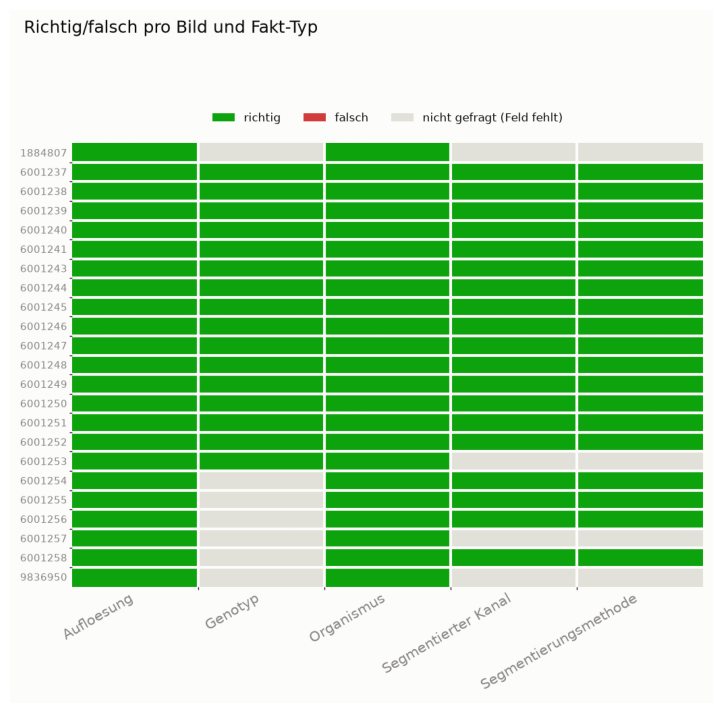

In [19]:
img = plt.imread(DATA_ROOT.parent / "rag_eval_heatmap.png")
fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(img)
ax.axis("off")
plt.show()

## Zusammenfassung: was das RAG kann und was (noch) nicht

**Kette komplett:** `metadata.json` (roh) -> `llm_chunker.py` (key_values per LLM
den Kategorien zuordnen) + strukturierte Felder direkt aus den Pixeldaten ->
Embeddings -> chromadb -> zwei Abrufe (eigenes Bild + ganzer Index) -> Kontext-Text
-> VLM-Antwort. Fuer 5 Fakt-Typen mit eindeutigem Ground Truth automatisiert
geprueft: **100/100 richtig** ueber alle 23 lokal vorhandenen IDR-Bilder.

**Was das NICHT zeigt:**
- Nur harte, eindeutig pruefbare Fakten (Organismus/Genotyp/Segmentierungsmethode/
  Kanal/Aufloesung). Fliesstext-Qualitaet (Protokoll-Details, Phaenotyp-
  Beschreibungen) bleibt beim manuellen Gegenlesen ueber `rag_test_questions.py`,
  siehe Block 4/5 oben und `RAG_TESTING.md`.
- Nur 23 Bilder, alle aus IDR - kein Test mit einer zweiten Quelle mit komplett
  anderem Metadatenschema (war der urspruengliche Anlass fuer `llm_chunker.py`,
  siehe Block 2 oben, aber noch nicht mit echten Fremd-Daten verifiziert).
- Unity-Seite (`RagClient.cs`) ungetestet auf dem Headset - dieses Notebook prueft
  nur die Python-Seite der Kette.
- Grading ist ein Wortstamm-Vergleich, kein LLM-als-Richter - robust gegen
  Uebersetzung/Umformulierung, aber kein Verstaendnis-Check. Ein Beispiel dafuer
  ist oben in Block 7 zu sehen (Block "Grading-Methode").